# 从 graph6 文件生成烃类 SMILES

## 目标
将 graph6 文件中的图结构转换为所有满足化学规则的烃类化合物（只含C和H）的 SMILES 表示。
- 枚举所有可能的单键/双键/三键组合
- 只保留化学合法的结构
- 输出规范化的 SMILES，用于后续与固定子结构连接

In [1]:
import networkx as nx
from rdkit import Chem
from rdkit.Chem import rdmolops, Draw
from itertools import product
from rdkit import RDLogger
import time

# 禁用 RDKit 警告日志
RDLogger.DisableLog('rdApp.*')

print("✓ 库导入成功!")

✓ 库导入成功!


## 配置参数

In [2]:
# ==============================================
# 配置参数
# ==============================================
g6_file = "D:/geng/graphs/graphs4.g6"                    # 输入: graph6 文件路径
output_file = "D:/geng/origin_smiles/4_C_smiles.txt"    # 输出: 烃类 SMILES 文件

# 允许的键类型：单键、双键、三键
# bond_types = [Chem.BondType.SINGLE, Chem.BondType.DOUBLE, Chem.BondType.TRIPLE]
bond_types = [Chem.BondType.SINGLE]

# 性能优化参数
MAX_BOND_COMBINATIONS = 20  # 限制每个图的最大键组合数，避免组合爆炸
BATCH_WRITE_SIZE = 1000      # 批量写入缓冲区大小
MAX_EDGES = 4                # 跳过边数过多的图（避免组合爆炸）

print(f"输入文件: {g6_file}")
print(f"输出文件: {output_file}")
print(f"最大键组合数: {MAX_BOND_COMBINATIONS}")
print(f"最大边数限制: {MAX_EDGES}")
print("-" * 60)

输入文件: D:/geng/graphs/graphs4.g6
输出文件: D:/geng/origin_smiles/4_C_smiles.txt
最大键组合数: 20
最大边数限制: 4
------------------------------------------------------------


## 辅助函数定义

In [3]:
def graph_to_mol(G):
    """
    将 NetworkX 图转换为 RDKit 分子对象（碳骨架，所有键初始为单键）。
    
    参数:
        G: NetworkX 图对象
    
    返回:
        RDKit Mol 对象，表示碳骨架分子
    """
    mol = Chem.RWMol()
    node_map = {}
    
    # 为图中每个节点创建碳原子
    for node in G.nodes:
        idx = mol.AddAtom(Chem.Atom(6))  # 原子序数 6 = 碳
        node_map[node] = idx
    
    # 为图中每条边创建单键
    for u, v in G.edges:
        mol.AddBond(node_map[u], node_map[v], Chem.BondType.SINGLE)
    
    return mol


def is_valid_valence_combination(bond_combo, num_atoms):
    """
    快速检查键组合是否可能满足碳的化合价要求。
    提前过滤明显不合理的组合。
    
    参数:
        bond_combo: 键类型的组合元组
        num_atoms: 分子中的原子数量
    
    返回:
        bool: True 表示可能合法，False 表示明显不合法
    """
    # 统计键的总价数
    total_bond_order = sum(
        1 if bt == Chem.BondType.SINGLE else 
        2 if bt == Chem.BondType.DOUBLE else 
        3 for bt in bond_combo
    )
    
    # 碳骨架每个碳最多4个价键
    # 这是粗略估计，真实情况需要 Sanitize 验证
    max_possible_bonds = num_atoms * 4
    if total_bond_order > max_possible_bonds:
        return False
    
    return True


def generate_multibond_combinations(mol, max_combinations=MAX_BOND_COMBINATIONS):
    """
    生成骨架分子的所有单键/双键/三键组合。
    使用生成器模式逐个输出，节省内存。
    
    参数:
        mol: RDKit Mol 对象（碳骨架）
        max_combinations: 最大生成的组合数量
    
    生成:
        RDKit Mol 对象，每个都是不同键类型组合的分子
    """
    bonds = list(mol.GetBonds())
    num_atoms = mol.GetNumAtoms()
    num_bonds = len(bonds)
    
    # 如果没有键，直接返回原分子
    if not bonds:
        yield mol
        return
    
    # 计算总组合数
    total_combinations = 3 ** num_bonds
    if total_combinations > max_combinations:
        print(f"    警告: {num_bonds}条边有{total_combinations}个组合，只生成前{max_combinations}个")
    
    count = 0
    
    # 遍历所有可能的键类型组合
    for combo in product(bond_types, repeat=num_bonds):
        # 提前进行化合价检查
        if not is_valid_valence_combination(combo, num_atoms):
            continue
        
        # 创建分子的可写副本
        rw_mol = Chem.RWMol(mol)
        
        # 设置每条键的类型
        for b, bt in zip(rw_mol.GetBonds(), combo):
            b.SetBondType(bt)
        
        try:
            # 检查分子的化学可行性（原子价、芳香性等）
            rdmolops.SanitizeMol(rw_mol)
            yield rw_mol
            
            count += 1
            # 达到最大数量后停止
            if count >= max_combinations:
                return
        except:
            # 不合法的组合直接跳过
            continue


print("✓ 辅助函数定义完成")

✓ 辅助函数定义完成


## 测试：读取并解析 graph6 文件

In [4]:
# 首先统计文件中的总图数
with open(g6_file, "r") as f:
    all_lines = [line.strip() for line in f if line.strip()]
    total_graphs = len(all_lines)

print(f"=== graph6 文件总览 ===")
print(f"文件路径: {g6_file}")
print(f"文件中总共有 {total_graphs} 个图")
print("=" * 50)

# 读取第一行作为测试
with open(g6_file, "r") as f:
    first_line = f.readline().strip()
    
print(f"\n=== 测试解析第一个图 ===")
print(f"graph6 字符串: {first_line}")
print(f"字符串长度: {len(first_line)}")

# 解析为 NetworkX 图
G = nx.from_graph6_bytes(first_line.encode())
print(f"\n图的节点数: {G.number_of_nodes()}")
print(f"图的边数: {G.number_of_edges()}")
print(f"节点列表: {list(G.nodes())}")
print(f"边列表: {list(G.edges())}")

print("\n" + "=" * 50)
print(f"✓ 文件 {g6_file} 共包含 {total_graphs} 个图")
print("=" * 50)

=== graph6 文件总览 ===
文件路径: D:/geng/graphs/graphs4.g6
文件中总共有 6 个图

=== 测试解析第一个图 ===
graph6 字符串: CF
字符串长度: 2

图的节点数: 4
图的边数: 3
节点列表: [0, 1, 2, 3]
边列表: [(0, 3), (1, 3), (2, 3)]

✓ 文件 D:/geng/graphs/graphs4.g6 共包含 6 个图


## 测试：第一个图生成烃类 SMILES

=== 测试第一个图的烃类生成 ===
图信息: 4 个节点, 3 条边

碳骨架 SMILES: CC(C)C
碳骨架原子数: 4
碳骨架键数: 3

理论键组合数: 3^3 = 27

    警告: 3条边有27个组合，只生成前20个
实际合法组合数: 1
唯一 SMILES 数: 1

生成的烃类 SMILES (前10个):
  1. CC(C)C

结构可视化 (前9个):


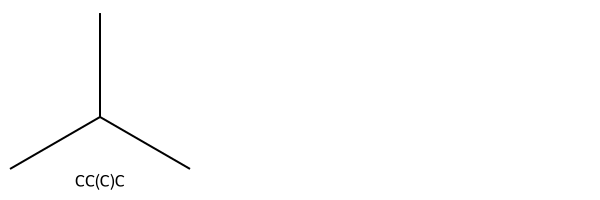

In [5]:
print("=== 测试第一个图的烃类生成 ===")
print(f"图信息: {G.number_of_nodes()} 个节点, {G.number_of_edges()} 条边\n")

# 转换为碳骨架
base_mol = graph_to_mol(G)
print(f"碳骨架 SMILES: {Chem.MolToSmiles(base_mol)}")
print(f"碳骨架原子数: {base_mol.GetNumAtoms()}")
print(f"碳骨架键数: {base_mol.GetNumBonds()}")
print(f"\n理论键组合数: 3^{base_mol.GetNumBonds()} = {3**base_mol.GetNumBonds()}\n")

# 生成所有键组合
test_smiles = set()
variant_count = 0

for mol_variant in generate_multibond_combinations(base_mol):
    smiles = Chem.MolToSmiles(mol_variant, canonical=True)
    test_smiles.add(smiles)
    variant_count += 1

print(f"实际合法组合数: {variant_count}")
print(f"唯一 SMILES 数: {len(test_smiles)}\n")

print("生成的烃类 SMILES (前10个):")
for i, smi in enumerate(sorted(test_smiles)[:10], 1):
    print(f"  {i}. {smi}")

if len(test_smiles) > 10:
    print(f"  ... 还有 {len(test_smiles) - 10} 个")

# 可视化前几个结构
print("\n结构可视化 (前9个):")
mols_to_show = [Chem.MolFromSmiles(smi) for smi in sorted(test_smiles)[:9]]
legends = [smi for smi in sorted(test_smiles)[:9]]
display(Draw.MolsToGridImage(mols_to_show, molsPerRow=3, subImgSize=(200,200), legends=legends))

## 主流程：批量处理所有图并生成 SMILES

In [6]:
print("="*60)
print("开始批量处理 graph6 文件")
print("="*60)
print(f"输入文件: {g6_file}")
print(f"输出文件: {output_file}")
print("-" * 60)

# 统计变量
total_molecules = 0      # 生成的唯一分子总数
unique_smiles = set()    # 用于去重的 SMILES 集合
line_count = 0           # 处理的图结构数量
write_buffer = []        # 批量写入缓冲区
skipped_graphs = 0       # 跳过的图数量

start_time = time.time()

# 打开输出文件，开始处理
with open(output_file, "w", encoding="utf-8") as fout:
    with open(g6_file, "r", encoding="utf-8") as fin:
        for line_num, line in enumerate(fin, 1):
            # 去除行首尾空白字符
            line = line.strip()
            
            # 跳过空行
            if not line:
                continue
            
            line_count += 1
            
            # ========== 步骤 1: 解析 graph6 格式 ==========
            try:
                G = nx.from_graph6_bytes(line.encode())
            except Exception as e:
                print(f"第 {line_num} 行: graph6 解析失败 - {e}")
                skipped_graphs += 1
                continue
            
            # ========== 性能优化：跳过边数过多的图 ==========
            num_edges = G.number_of_edges()
            if num_edges > MAX_EDGES:
                print(f"    跳过第 {line_num} 行: 边数过多 ({num_edges}), 会导致组合爆炸")
                skipped_graphs += 1
                continue
            
            # ========== 步骤 2: 转换为 RDKit 碳骨架分子 ==========
            base_mol = graph_to_mol(G)
            
            # ========== 步骤 3: 生成所有键类型组合 ==========
            batch_smiles = set()
            
            for mol_variant in generate_multibond_combinations(base_mol):
                try:
                    # 生成规范化 SMILES
                    smiles = Chem.MolToSmiles(mol_variant, canonical=True)
                    batch_smiles.add(smiles)
                except Exception:
                    continue
            
            # ========== 批量去重和写入 ==========
            for smiles in batch_smiles:
                if smiles not in unique_smiles:
                    unique_smiles.add(smiles)
                    write_buffer.append(smiles + "\n")
                    total_molecules += 1
                    
                    # 当缓冲区达到一定大小时，批量写入文件
                    if len(write_buffer) >= BATCH_WRITE_SIZE:
                        fout.writelines(write_buffer)
                        write_buffer.clear()
            
            # 每处理 10 行输出一次进度信息
            if line_num % 10 == 0:
                elapsed = time.time() - start_time
                speed = line_count / elapsed if elapsed > 0 else 0
                print(f"已处理 {line_num} 行 ({line_count} 有效), "
                      f"生成 {total_molecules} 个唯一分子, "
                      f"速度: {speed:.2f} 图/秒")
    
    # ========== 写入剩余的缓冲区数据 ==========
    if write_buffer:
        fout.writelines(write_buffer)
        write_buffer.clear()

# ==============================================
# 输出最终统计信息
# ==============================================
elapsed_time = time.time() - start_time
print("=" * 60)
print(f"处理完成!")
print(f"总共读取了 {line_num} 行")
print(f"有效处理了 {line_count} 个图结构")
print(f"跳过了 {skipped_graphs} 个图")
print(f"生成了 {total_molecules} 个唯一烃类分子 (已去重)")
print(f"总用时: {elapsed_time:.2f} 秒")
print(f"平均速度: {line_count/elapsed_time:.2f} 图/秒")
print(f"输出文件: {output_file}")
print("=" * 60)

开始批量处理 graph6 文件
输入文件: D:/geng/graphs/graphs4.g6
输出文件: D:/geng/origin_smiles/4_C_smiles.txt
------------------------------------------------------------
    警告: 3条边有27个组合，只生成前20个
    警告: 3条边有27个组合，只生成前20个
    警告: 4条边有81个组合，只生成前20个
    警告: 4条边有81个组合，只生成前20个
    跳过第 5 行: 边数过多 (5), 会导致组合爆炸
    跳过第 6 行: 边数过多 (6), 会导致组合爆炸
处理完成!
总共读取了 6 行
有效处理了 6 个图结构
跳过了 2 个图
生成了 4 个唯一烃类分子 (已去重)
总用时: 0.00 秒
平均速度: 4042.70 图/秒
输出文件: D:/geng/origin_smiles/4_C_smiles.txt


## 验证输出文件

=== 输出文件验证 ===
文件: D:/geng/origin_smiles/4_C_smiles.txt
总分子数: 4

前10个 SMILES:
  1. CC(C)C (C4H10)
  2. CCCC (C4H10)
  3. CC1CC1 (C4H8)
  4. C1CCC1 (C4H8)

随机展示 12 个分子结构:


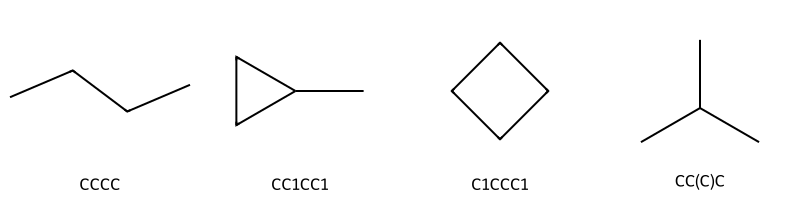

In [7]:
# 读取生成的 SMILES 文件并验证
with open(output_file, "r", encoding="utf-8") as f:
    generated_smiles = [line.strip() for line in f if line.strip()]

print(f"=== 输出文件验证 ===")
print(f"文件: {output_file}")
print(f"总分子数: {len(generated_smiles)}")
print("\n前10个 SMILES:")
for i, smi in enumerate(generated_smiles[:10], 1):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        num_c = sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == 'C')
        num_h = sum(atom.GetTotalNumHs() for atom in mol.GetAtoms())
        print(f"  {i}. {smi} (C{num_c}H{num_h})")
    else:
        print(f"  {i}. {smi} (解析失败!)")

if len(generated_smiles) > 10:
    print(f"  ... 还有 {len(generated_smiles) - 10} 个")

# 随机展示一些结构
import random
print("\n随机展示 12 个分子结构:")
sample_size = min(12, len(generated_smiles))
sample_smiles = random.sample(generated_smiles, sample_size)
sample_mols = [Chem.MolFromSmiles(smi) for smi in sample_smiles]
display(Draw.MolsToGridImage(sample_mols, molsPerRow=4, subImgSize=(200,200), legends=sample_smiles))